[*********************100%***********************]  1 of 1 completed

Buy andf hold return: -1.0
strategy return: -1.0


,Close,Adj Close,ema26,ema12,MACD,signal,position,cc_return,strategy_return,cumulative_market,cumulative_return
Date,,,,,,,,,,,
2021-03-12,387.029999,385.419800,387.029999,387.029999,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN
2021-03-15,383.730011,382.133545,386.785555,386.522308,-0.263247,-0.052649,-1.0,-0.008526,0.008526,-0.008526,0.008526
2021-03-16,380.640015,379.056366,386.330330,385.617340,-0.712990,-0.184717,-1.0,-0.008053,0.008053,-0.016510,0.016648
2021-03-17,373.670013,372.115417,385.392529,383.779290,-1.613239,-0.470422,-1.0,-0.018311,0.018311,-0.034519,0.035264
2021-03-18,366.079987,364.556946,383.961970,381.056320,-2.905650,-0.957467,-1.0,-0.020312,0.020312,-0.054130,0.056292


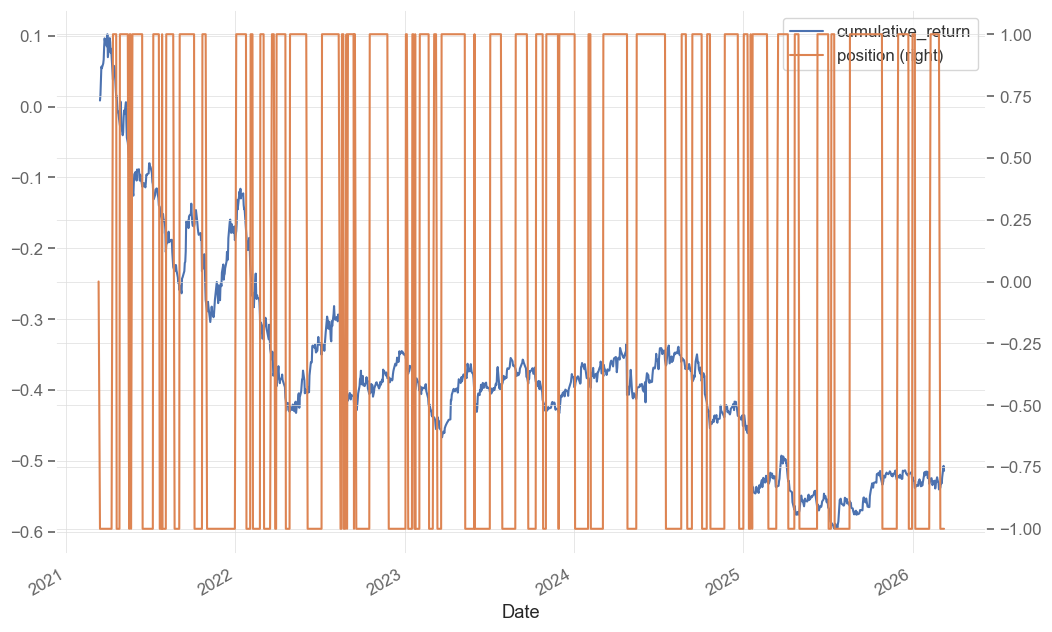

In [45]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf
import quantstats as qs
import warnings

warnings.filterwarnings('ignore')

end1=datetime.date(2026,3,11)
start1=end1-pd.Timedelta(days=365*5)

df=yf.download('KOTAKBANK.NS',start=start1,end=end1,auto_adjust=False,multi_level_index=False)

df=df[['Open','High','Low','Close','Volume','Adj Close']]
df=df.drop(['Open','High','Low','Volume'],axis=1)

df['ema26']=df['Close'].ewm(span=26,adjust=False).mean()
df['ema12']=df['Close'].ewm(span=12,adjust=False).mean()
df['MACD']=df['ema12']-df['ema26']

df['signal']=df['MACD'].ewm(span=9,adjust=False).mean()

df['position']=np.where(df['MACD']>df['signal'],1,-1)
df['position']=df['position'].shift(1).fillna(0)

df['cc_return']=df['Close'].pct_change()

df['strategy_return']=df['position']*df['cc_return']

df['cumulative_market'] = (1 + df['cc_return']).cumprod() - 1
df['cumulative_return']=(1 + df['strategy_return']).cumprod() - 1

df[['cumulative_return', 'position']].plot(figsize=(12, 8), secondary_y='position',grid=True)

print('Buy andf hold return:',np.round(df['cumulative_market'].cumprod()[-1]-1,2))
print('strategy return:',np.round(df['cumulative_return'].cumprod()[-1]-1,2))

df.head()